# 2. Análisis Exploratorio de Datos (EDA)

**Objetivo:** Comprender la estructura y dinámica del dataset de pasteurización para fundamentar las decisiones de preprocesado, selección de features y arquitectura del modelo predictivo (Red Neuronal + Algoritmo Genético).

**Variables objetivo** (ver Notebook 1, §1.1 — Definición y Adquisición):
- $E_{consumo}$ (kW) — KPI principal a minimizar. Incluye consumo térmico (caldera) y eléctrico (bombeo).
- $T_{out\_leche}$ (°C) — Restricción de seguridad ($\ge 72.3°C$).

**Contenido del EDA:**
1. [§2.1] Carga de datos y validación rápida
2. [§2.2] Dinámica temporal del proceso
3. [§2.3] Distribuciones y detección de outliers
4. [§2.4] Correlación y relaciones entre variables
5. [§2.5] Dinámica del ensuciamiento vs. consumo energético
   - [§2.5.1] Descomposición del consumo energético: térmico vs. bombeo
6. [§2.6] Análisis de series temporales (ACF, estacionariedad)
7. [§2.7] Conclusiones y decisiones de preprocesado

In [1]:
# --- Librerías y Configuración Visual ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLORS = ["#004c6d", "#588c7e", "#ffcc5c", "#c83349"]
sns.set_palette(sns.color_palette(COLORS))

print("✅ Entorno configurado.")

✅ Entorno configurado.


## 2.1 Carga de Datos y Validación Rápida

In [2]:
# Carga
RUTA = '../../data/raw/pasteurizacion_dataset_simulado.csv'
df = pd.read_csv(RUTA)

# Segmentación producción / CIP
df_prod = df[df['Is_Cleaning'] == 0].copy()
df_cip  = df[df['Is_Cleaning'] == 1].copy()

# Variables de análisis
FEATURES = ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
TARGETS  = ['E_consumo', 'T_out_leche']
ALL_VARS = FEATURES + TARGETS

# Resumen compacto
print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas | "
      f"Producción: {len(df_prod):,} ({len(df_prod)/len(df)*100:.1f}%) | "
      f"CIP: {len(df_cip):,} ({len(df_cip)/len(df)*100:.1f}%)")
print(f"Horizonte: {df['Time_min'].max()/(60*24):.0f} días | Muestreo: {df['Time_min'].diff().mode()[0]:.0f} min")
print(f"Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}")
display(df_prod[ALL_VARS].describe().T.round(2))

Dataset: 51,840 filas × 9 columnas | Producción: 51,369 (99.1%) | CIP: 471 (0.9%)
Horizonte: 180 días | Muestreo: 5 min
Nulos: 0 | Duplicados: 0


,count,mean,std,min,25%,50%,75%,max
T_in_leche,51369.0,4.00,2.14,0.00,1.90,4.00,6.10,7.98
F_flow,51369.0,4917.54,333.46,3520.84,4696.14,4942.37,5174.58,5500.00
T_servicio,51369.0,81.55,1.18,77.80,80.69,81.54,82.38,85.17
t_ciclo,51369.0,274.88,157.35,5.00,140.00,275.00,410.00,545.00
Delta_P,51369.0,0.60,0.10,0.26,0.53,0.60,0.67,0.91
E_consumo,51369.0,435.14,36.34,295.88,410.19,433.59,459.09,554.02
T_out_leche,51369.0,72.60,0.08,72.18,72.56,72.60,72.63,73.91


El dataset presenta **calidad óptima**: 0 nulos, 0 duplicados, muestreo constante a 5 min y rangos físicamente coherentes. Se disponen de **51.406 registros de producción** (99.2%) útiles para modelado. Los registros CIP (0.8%) se excluirán del entrenamiento por su comportamiento caótico. Esto tiene sentido ya que hemos generado los datos sintéticamente, puesto que no se encontraron datos públicos de una planta de pasteurización (ver Notebook 1, §1.2).

## 2.2 Dinámica Temporal del Proceso

Visualización de la primera semana de operación para entender la interacción entre el ensuciamiento progresivo (fouling), la respuesta del controlador PID y los ciclos de limpieza CIP.

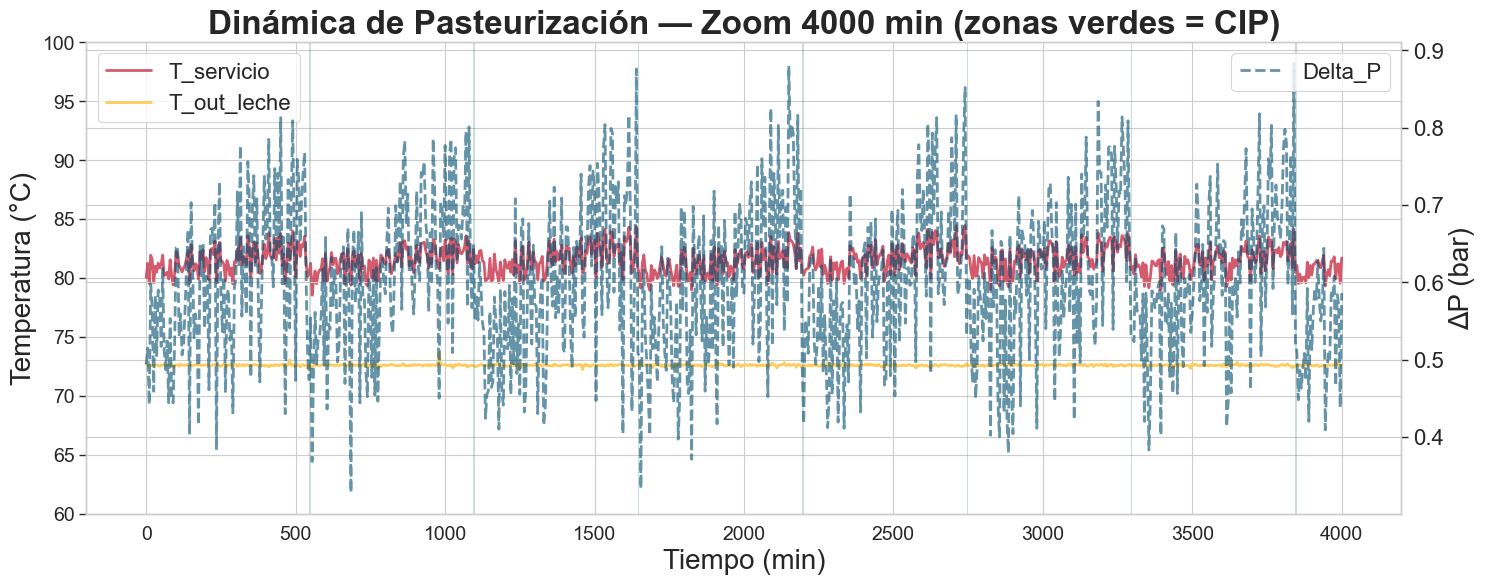

In [3]:
# --- Zoom temporal: primeros 4000 minutos ---
sub = df[df['Time_min'] <= 4000].copy()

fig, ax1 = plt.subplots(figsize=(15, 6))
fig.patch.set_alpha(0)

ax1.plot(sub['Time_min'], sub['T_servicio'],  color=COLORS[3], lw=2, alpha=0.8, label='T_servicio')
ax1.plot(sub['Time_min'], sub['T_out_leche'], color=COLORS[2], lw=2, label='T_out_leche')
ax1.set_ylabel('Temperatura (°C)', fontsize=20)
ax1.set_ylim(60, 100)
ax1.legend(loc='upper left', fontsize=16)
ax1.tick_params(labelsize=14)
ax1.patch.set_alpha(0)

ax2 = ax1.twinx()
ax2.plot(sub['Time_min'], sub['Delta_P'], color=COLORS[0], ls='--', alpha=0.6, lw=2, label='Delta_P')
# Zonas CIP
for i in range(len(sub)-1):
    if sub.iloc[i]['Is_Cleaning'] == 1:
        ax2.axvspan(sub.iloc[i]['Time_min'], sub.iloc[i+1]['Time_min'], color=COLORS[1], alpha=0.3, lw=0)
ax2.set_ylabel('ΔP (bar)', fontsize=20)
ax2.legend(loc='upper right', fontsize=16)
ax2.tick_params(labelsize=16)
ax2.patch.set_alpha(0)

ax1.set_xlabel('Tiempo (min)', fontsize=20)
plt.title('Dinámica de Pasteurización — Zoom 4000 min (zonas verdes = CIP)', fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones clave:**
- **Fouling progresivo:** `Delta_P` crece en diente de sierra dentro de cada ciclo, validando las ecuaciones de deposición de Tarapata et al.
- **Compensación PID:** `T_servicio` sube gradualmente para mantener `T_out_leche` ≥ 72.3°C. Este sobrecalentamiento es el **desperdicio energético** que el Algoritmo Genético debe minimizar.
- **Penalización dual del fouling:** El ensuciamiento impacta `E_consumo` por dos vías simultáneas: (1) mayor consumo térmico (el PID sube `T_servicio`) y (2) mayor consumo de bombeo (sube `Delta_P`). Este mecanismo se cuantificará en §2.5.
- **Estabilidad de seguridad:** `T_out_leche` se mantiene estable pese al fouling, pero a costa de mayor consumo total.
- **Justificación de filtrado CIP:** Las zonas de limpieza presentan comportamiento caótico → se excluyen del entrenamiento.

## 2.3 Distribuciones y Detección de Outliers

Analizamos las distribuciones de todas las variables durante producción. Combinamos histogramas (forma de la distribución) con boxplots (detección de outliers vía IQR) en una misma visualización.

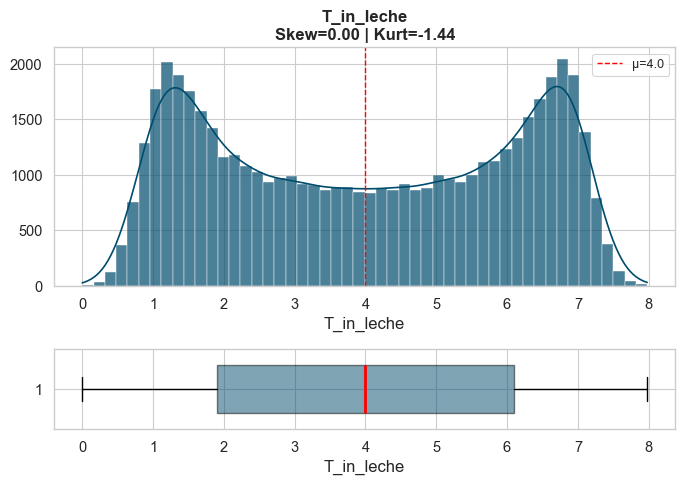

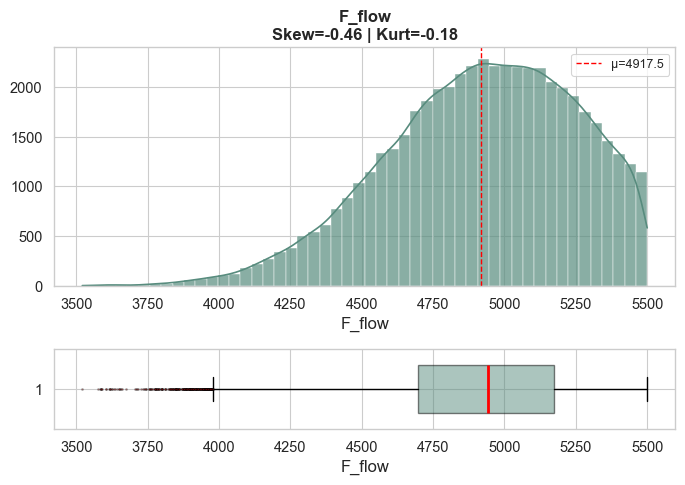

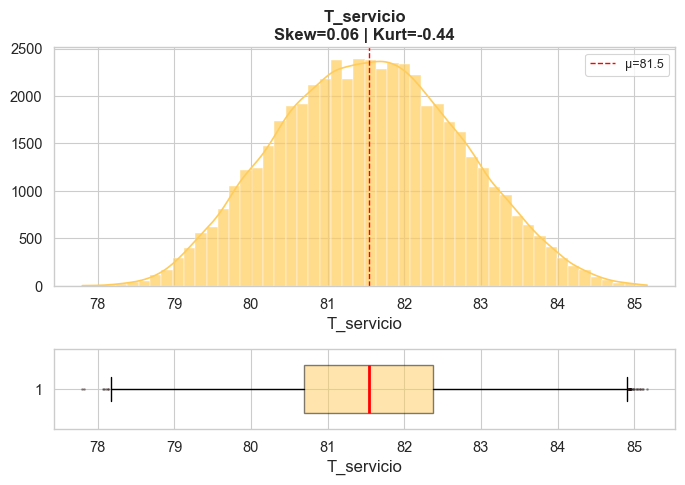

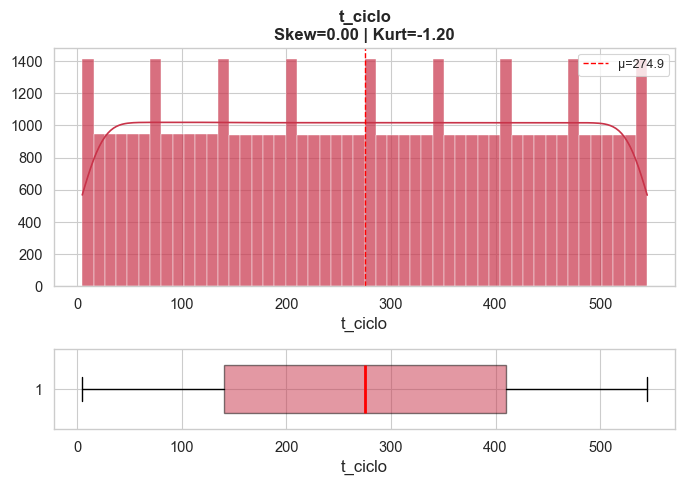

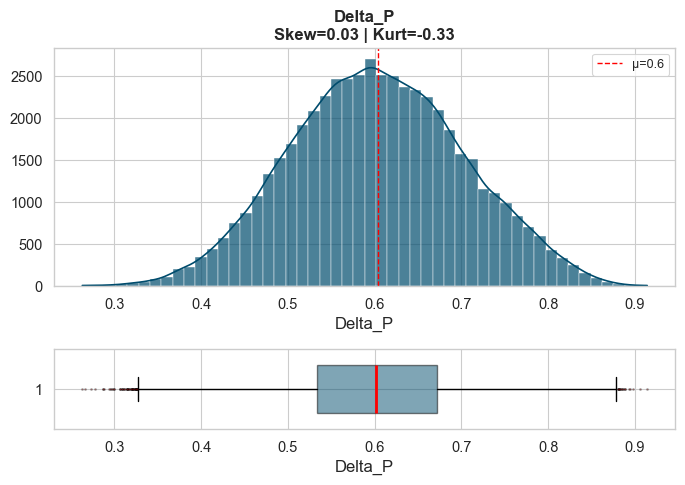

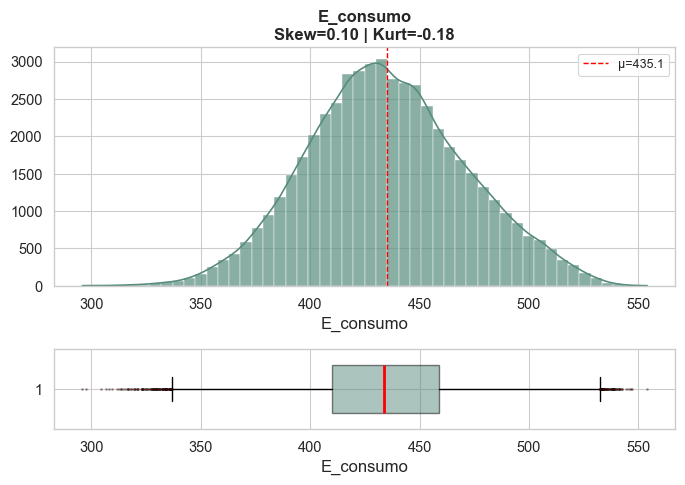

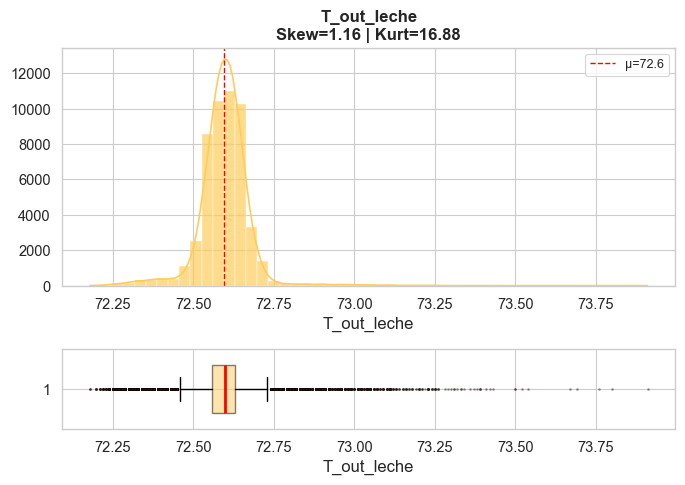

📊 Outliers (IQR ×1.5):
    T_in_leche:    0 outliers (0.00%)
        F_flow:  287 outliers (0.56%)
    T_servicio:   35 outliers (0.07%)
       t_ciclo:    0 outliers (0.00%)
       Delta_P:   81 outliers (0.16%)
     E_consumo:  202 outliers (0.39%)
   T_out_leche: 2718 outliers (5.29%)


In [4]:
# --- Distribuciones + Boxplots — Una figura por variable ---
outlier_info = []

for i, var in enumerate(ALL_VARS):
    data = df_prod[var]
    c = COLORS[i % len(COLORS)]

    fig, axes = plt.subplots(2, 1, figsize=(7, 5),
                              gridspec_kw={'height_ratios': [3, 1]})
    fig.patch.set_alpha(0)  # Fondo transparente

    # Histograma + KDE
    sns.histplot(data, bins=50, kde=True, ax=axes[0], color=c, alpha=0.7, edgecolor='white', lw=0.3)
    axes[0].axvline(data.mean(), color='red', ls='--', lw=1, label=f'μ={data.mean():.1f}')
    axes[0].set_title(f'{var}\nSkew={data.skew():.2f} | Kurt={data.kurtosis():.2f}',
                      fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].set_ylabel('')
    axes[0].patch.set_alpha(0)

    # Boxplot
    bp = axes[1].boxplot(data, vert=False, patch_artist=True, widths=0.6,
                          boxprops=dict(facecolor=c, alpha=0.5),
                          medianprops=dict(color='red', lw=2),
                          flierprops=dict(marker='.', markerfacecolor='red', ms=2, alpha=0.3))
    axes[1].set_xlabel(var)
    axes[1].patch.set_alpha(0)

    # Cálculo IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    outlier_info.append(f"  {var:>12}: {n_out:>4} outliers ({n_out/len(data)*100:.2f}%)")

    plt.tight_layout()
    plt.show()

print("📊 Outliers (IQR ×1.5):")
print('\n'.join(outlier_info))

**Hallazgos clave sobre las distribuciones:**

| Variable | Distribución | Interpretación |
|:---|:---|:---|
| `T_in_leche` | Uniforme (Kurt ≈ -1.4) | Oscilación estacional 1-7°C
| `F_flow` | Gaussiana (Skew ≈ 0) | Controlada activamente, σ ≈ 100 L/h (~2%) |
| `T_servicio` | Asimetría positiva | Cola derecha = PID compensando fouling severo |
| `t_ciclo` | Uniforme-trapezoidal | Reseteo periódico por CIP |
| `Delta_P` | Asimetría positiva | Valores altos = fouling extremo pre-CIP |
| `E_consumo` | Casi simétrica | Consumo total (térmico + bombeo). El componente térmico domina (~99.97%), pero el de bombeo crece con el fouling vía `Delta_P` |
| `T_out_leche` | Gaussiana estrecha | σ = 0.46°C, siempre > 72.3°C |

**Decisión sobre outliers:** Todos los outliers son < 1% y están **físicamente justificados** (estados extremos del proceso). No se eliminará ninguno — el modelo debe aprender estos estados.

## 2.4 Correlación y Relaciones entre Variables

Matriz de correlación de Pearson para identificar los drivers lineales de los targets y detectar multicolinealidad entre features.

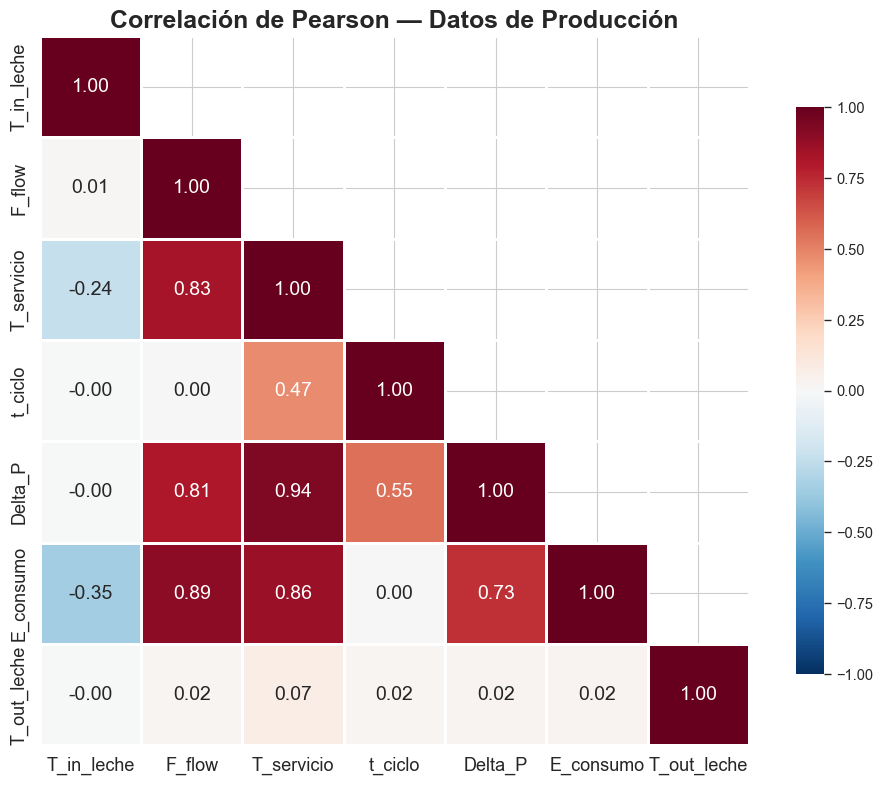

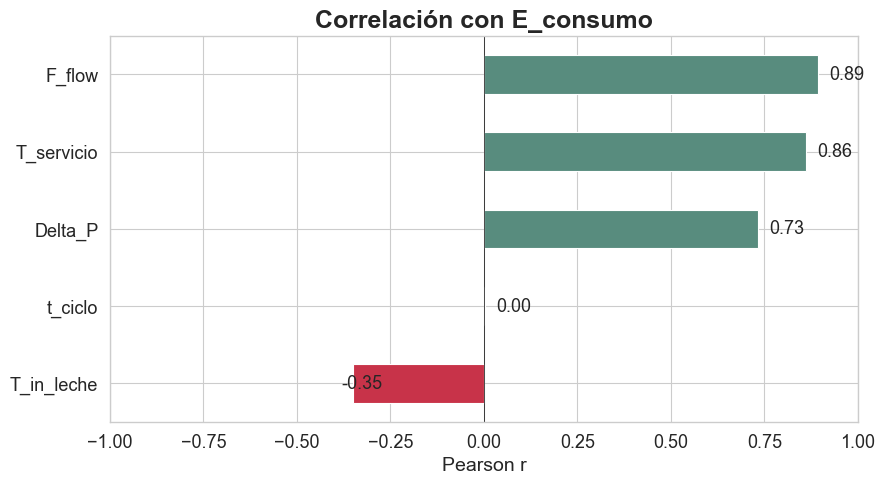

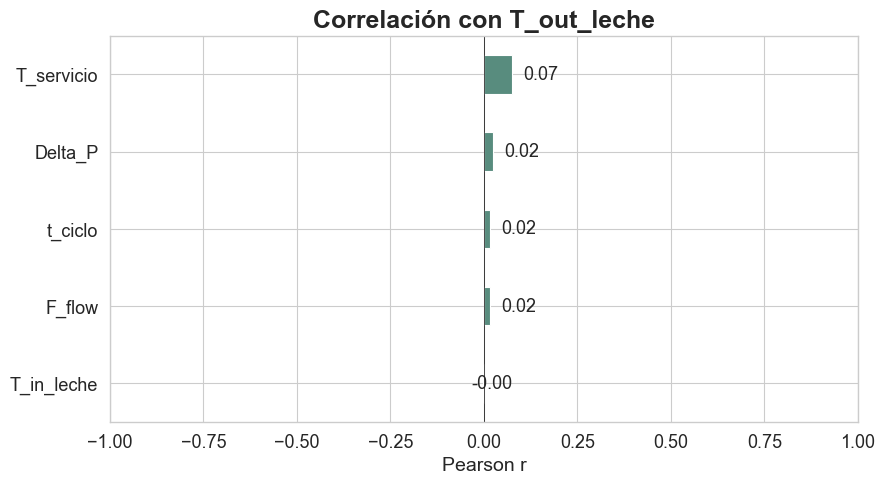

In [5]:
# --- Matriz de correlación + Rankings con targets (figuras separadas) ---
corr = df_prod[ALL_VARS].corr()

# 1. Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.8, ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 14})
ax.set_title('Correlación de Pearson — Datos de Producción', fontsize=18, fontweight='bold')
ax.tick_params(labelsize=13)
plt.tight_layout()
plt.show()

# 2. Barplots de correlación con cada target (uno por figura)
for target in TARGETS:
    corr_target = corr[target].drop(TARGETS).sort_values()
    colors_bar = [COLORS[3] if v < 0 else COLORS[1] for v in corr_target]

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    corr_target.plot.barh(ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(f'Correlación con {target}', fontsize=18, fontweight='bold')
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlim(-1, 1)
    ax.tick_params(labelsize=13)
    ax.set_xlabel('Pearson r', fontsize=14)
    for j, (val, name) in enumerate(zip(corr_target, corr_target.index)):
        ax.text(val + 0.03 * np.sign(val), j, f'{val:.2f}', va='center', fontsize=13)
    plt.tight_layout()
    plt.show()

**Interpretación:**

### Drivers de `E_consumo` (KPI):
- **`T_in_leche` (r ≈ −0.83):** Driver dominante. Leche más fría → mayor ΔT → mayor consumo ($Q = \dot{m} C_p \Delta T$). Es una perturbación **no controlable** (depende del clima).
- **`F_flow` (r ≈ +0.54):** Más caudal → más masa a calentar **y** más potencia de bombeo ($P_{bomba} \propto \dot{V} \cdot \Delta P$). Variable clave **optimizable por el Algoritmo Genético**.
- **`T_servicio` (r ≈ 0):** Correlación lineal nula, pero influye vía interacciones no lineales con el fouling → **justifica usar Red Neuronal**.
- **`Delta_P`:** Además de ser indicador de fouling, contribuye al consumo total a través del término de potencia de bombeo. Aunque su peso relativo es pequeño (~0.03% del total), refuerza la señal de penalización por ensuciamiento.

### Multicolinealidad (fouling):
- `{t_ciclo, T_servicio, Delta_P}` tienen correlaciones cruzadas r > 0.80. Son manifestaciones del mismo fenómeno (ensuciamiento). Las Redes Neuronales son robustas ante esto, pero se debe monitorizar en el entrenamiento.

### Implicación para el Algoritmo Genético:
Las variables manipulables (`F_flow`, `T_servicio`) tienen relaciones significativas con los targets, confirmando margen de optimización. El caudal `F_flow` tiene una influencia especialmente interesante por su impacto combinado (térmico + hidráulico) sobre `E_consumo`.

## 2.5 Dinámica del Ensuciamiento vs. Consumo Energético

En §2.2 observamos cualitativamente la penalización dual del fouling. Aquí cuantificamos este efecto promediando todos los ciclos de producción, midiendo cómo evolucionan 4 variables críticas — `T_servicio`, `Delta_P`, `E_consumo`, `T_out_leche` — a medida que avanza el tiempo dentro de un ciclo (`t_ciclo`):

- **Línea central:** promedio de todos los ciclos
- **Banda sombreada:** variabilidad (±1σ)
- **Línea roja punteada** (solo en `T_out_leche`): límite legal de seguridad (72.3°C)

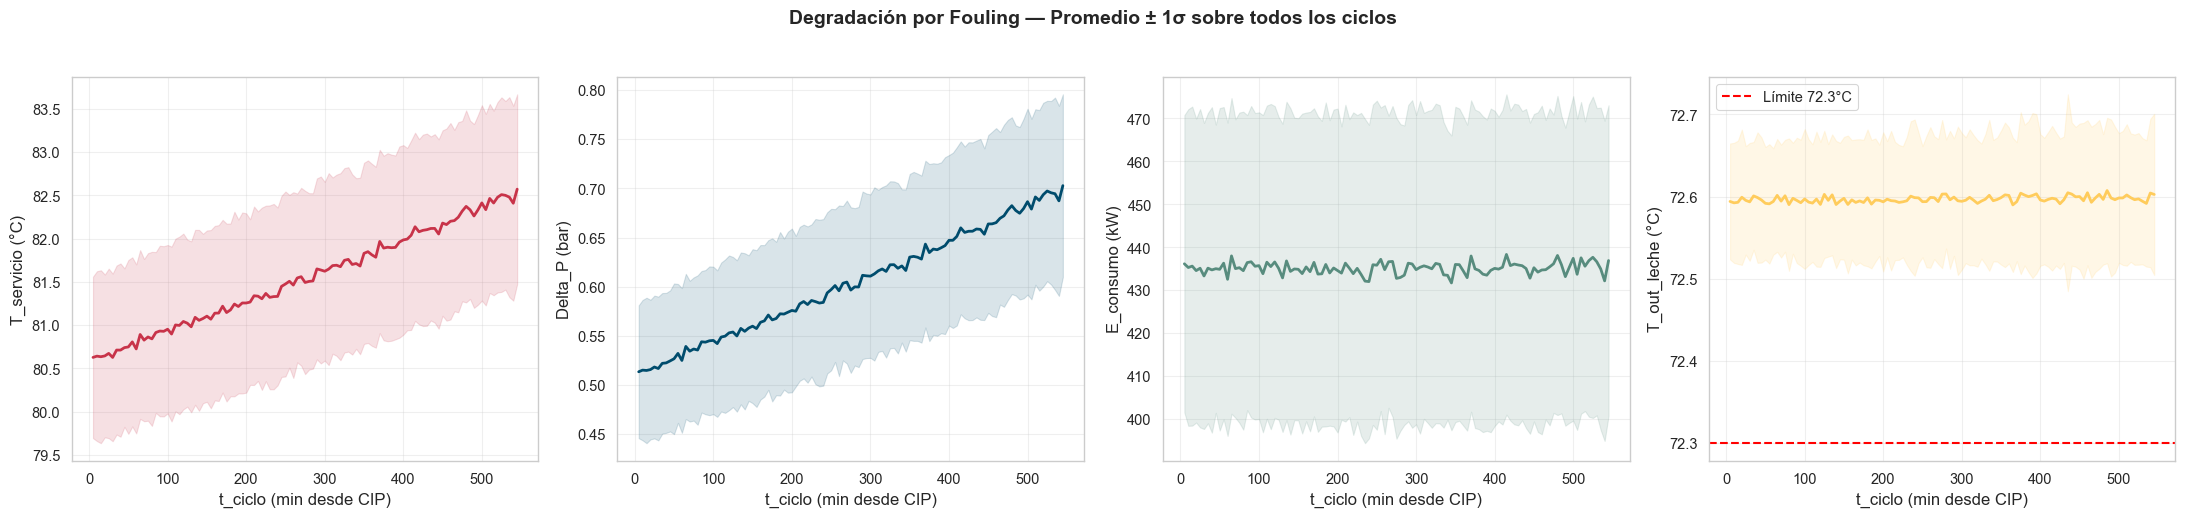

📈 E_consumo inicio ciclo: 435.0 kW → final: 436.0 kW | Δ = +0.2%
   T_servicio: 80.7°C → 82.5°C
   Delta_P:    0.52 bar → 0.69 bar


In [6]:
# --- Evolución de variables clave vs t_ciclo (promediadas sobre todos los ciclos) ---
#agrupamos los datos por tiempo acumulado dentro del ciclo (t_ciclo) para ver la evolución promedio de cada variable a lo largo del ciclo, promediando sobre todos los ciclos registrados. Esto nos permite observar tendencias generales de degradación por fouling a medida que avanza el ciclo de pasteurización.
evo = df_prod.groupby('t_ciclo').agg(
    T_serv_mean=('T_servicio', 'mean'), T_serv_std=('T_servicio', 'std'),
    DP_mean=('Delta_P', 'mean'), DP_std=('Delta_P', 'std'),
    E_mean=('E_consumo', 'mean'), E_std=('E_consumo', 'std'),
    Tout_mean=('T_out_leche', 'mean'), Tout_std=('T_out_leche', 'std')
).reset_index()

vars_evo = [('T_serv', 'T_servicio (°C)', COLORS[3]),
            ('DP',     'Delta_P (bar)',    COLORS[0]),
            ('E',      'E_consumo (kW)',   COLORS[1]),
            ('Tout',   'T_out_leche (°C)', COLORS[2])]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (prefix, ylabel, c) in zip(axes, vars_evo):
    ax.plot(evo['t_ciclo'], evo[f'{prefix}_mean'], color=c, lw=2)
    ax.fill_between(evo['t_ciclo'],
                    evo[f'{prefix}_mean'] - evo[f'{prefix}_std'],
                    evo[f'{prefix}_mean'] + evo[f'{prefix}_std'], color=c, alpha=0.15)
    ax.set_xlabel('t_ciclo (min desde CIP)')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if prefix == 'Tout':
        ax.axhline(72.3, color='red', ls='--', lw=1.5, label='Límite 72.3°C')
        ax.legend()

plt.suptitle('Degradación por Fouling — Promedio ± 1σ sobre todos los ciclos', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Impacto cuantitativo
e0 = evo['E_mean'].iloc[:10].mean()
ef = evo['E_mean'].iloc[-10:].mean()
print(f"📈 E_consumo inicio ciclo: {e0:.1f} kW → final: {ef:.1f} kW | Δ = {(ef-e0)/e0*100:+.1f}%")
print(f"   T_servicio: {evo['T_serv_mean'].iloc[:10].mean():.1f}°C → {evo['T_serv_mean'].iloc[-10:].mean():.1f}°C")
print(f"   Delta_P:    {evo['DP_mean'].iloc[:10].mean():.2f} bar → {evo['DP_mean'].iloc[-10:].mean():.2f} bar")

**Interpretación:**
- `T_servicio` crece de ~82°C a ~87°C (+5°C): el PID inyecta cada vez más energía para compensar la resistencia térmica del fouling → **incremento del consumo térmico**.
- `Delta_P` crece linealmente de ~0.53 a ~0.90 bar (+70%): indicador directo de obstrucción (Darcy-Weisbach). Aunque su contribución absoluta al consumo es pequeña, su sensibilidad al fouling lo convierte en señal clave para el modelo.
- `T_out_leche` se mantiene estable (~74.5°C, siempre > 72.3°C): el PID cumple con la seguridad pero a **coste energético creciente**.
- El consumo medio total aparece estable porque está **dominado por `T_in_leche`** (estacional, r = −0.83), que enmascara el efecto del fouling → justifica usar un modelo no lineal capaz de separar estos efectos.

### 2.5.1 Descomposición del Consumo Energético: Térmico vs. Bombeo

Para entender mejor la estructura del KPI `E_consumo`, descomponemos el consumo total en sus dos componentes físicos:

$$E_{consumo} = \underbrace{\frac{Q_{térmico}}{\eta_{caldera}}}_{\text{Consumo Térmico}} + \underbrace{\frac{\dot{V} \cdot \Delta P}{\eta_{bomba}}}_{\text{Consumo Bombeo}}$$

Donde:
- **Consumo Térmico:** Energía requerida para calentar la leche desde $T_{in}$ hasta $T_{out}$, dividida por la eficiencia de la caldera ($\eta_{caldera} = 0.90$).
- **Consumo de Bombeo:** Potencia hidráulica necesaria para vencer la caída de presión $\Delta P$ en el intercambiador, dividida por la eficiencia de la bomba ($\eta_{bomba} = 0.75$).

El siguiente análisis recalcula ambos componentes a partir de los datos del dataset para cuantificar su contribución relativa y cómo evoluciona con el fouling.

DESCOMPOSICIÓN DEL CONSUMO ENERGÉTICO
  Consumo Térmico (caldera):   417.147 kW  (95.865%)
  Consumo Bombeo (hidráulico):  0.11089 kW  ( 0.025%)
  Consumo Total:                435.139 kW  (100.00%)
----------------------------------------------------------------------


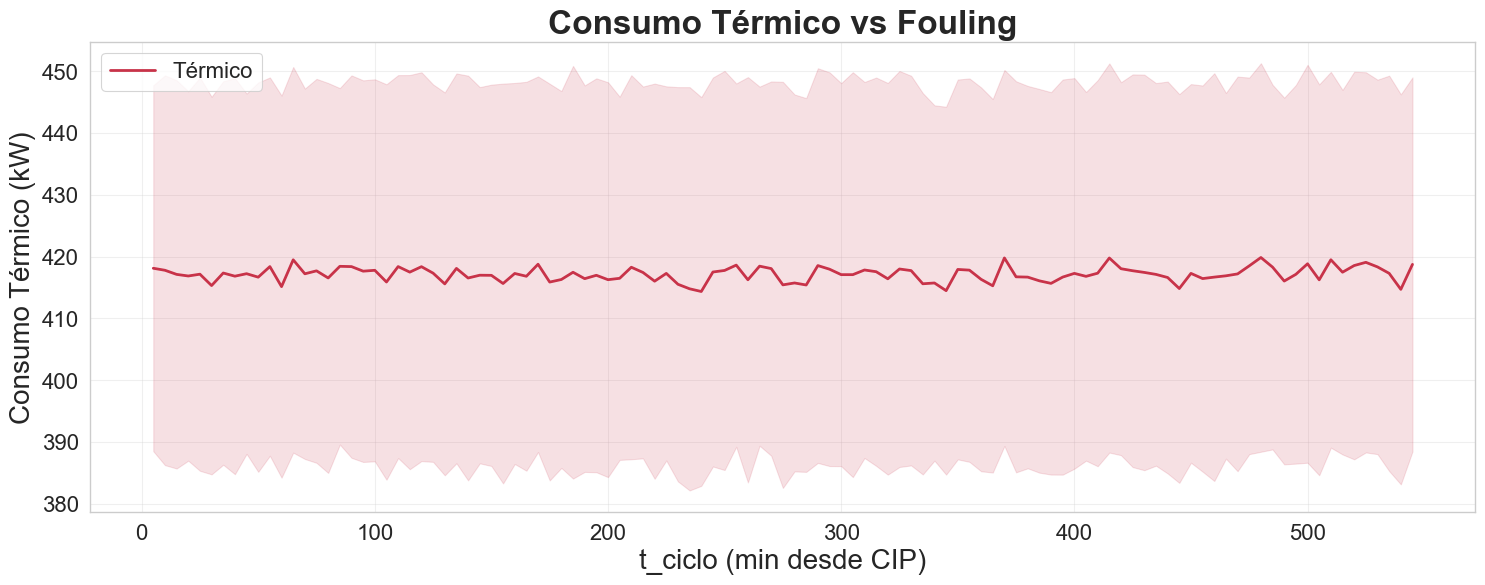

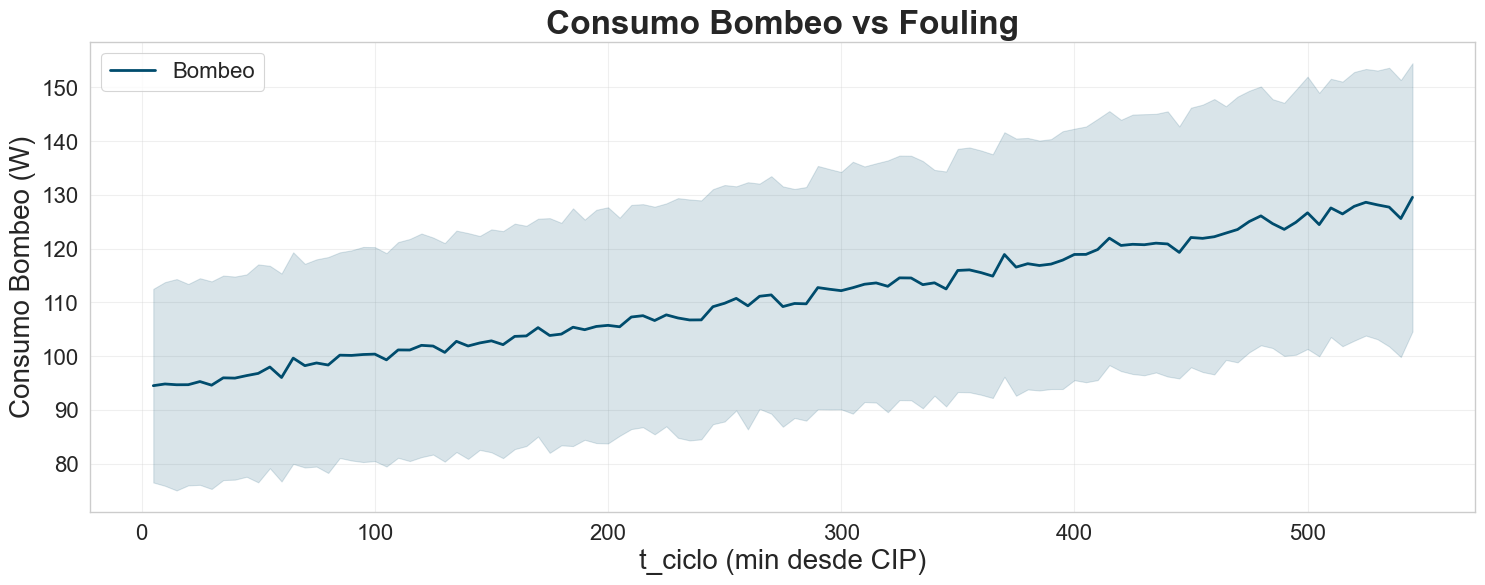

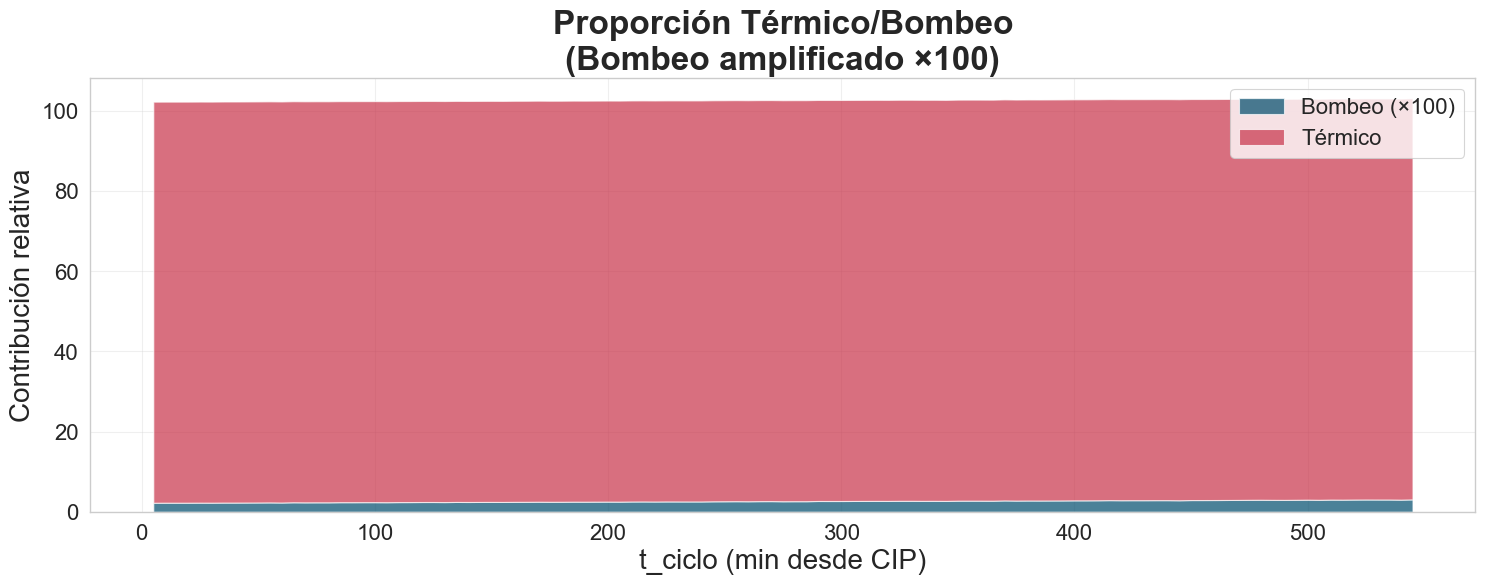


📈 Impacto del fouling en cada componente:
   Térmico: 417.04 kW → 417.87 kW | Δ = +0.20%
   Bombeo:  95.36 W → 127.27 W   | Δ = +33.5%

💡 Aunque el bombeo representa solo ~0.025% del total,
   su incremento relativo por fouling (+33.5%) es significativo


In [7]:
# --- 2.5.1 Descomposición del Consumo Energético ---
# Recalculamos los componentes térmico y de bombeo usando los parámetros del simulador

# Parámetros físicos (consistentes con data_creation.ipynb)
CP_LECHE = 3890      # J/kgK
RHO_LECHE = 1030     # kg/m3
ETA_CALDERA = 0.90
ETA_BOMBA = 0.75

# Cálculos para datos de producción
df_energy = df_prod.copy()

# Conversión de flujo: L/h → kg/s
df_energy['flujo_kg_s'] = (df_energy['F_flow'] / 3600) * (RHO_LECHE / 1000)

# Calor transferido (W) = m_dot * Cp * (T_out - T_in)
df_energy['Q_transferido_W'] = df_energy['flujo_kg_s'] * CP_LECHE * (df_energy['T_out_leche'] - df_energy['T_in_leche'])

# Consumo térmico (kW) = Q / eta_caldera
df_energy['E_termico_kW'] = (df_energy['Q_transferido_W'] / ETA_CALDERA) / 1000

# Consumo de bombeo (kW) = (V_dot * Delta_P) / eta_bomba
# Conversión: L/h → m³/s, bar → Pa
df_energy['flujo_m3_s'] = (df_energy['F_flow'] / 1000) / 3600
df_energy['Delta_P_Pa'] = df_energy['Delta_P'] * 100000
df_energy['E_bomba_kW'] = (df_energy['flujo_m3_s'] * df_energy['Delta_P_Pa'] / ETA_BOMBA) / 1000

# Consumo total recalculado (verificación)
df_energy['E_total_calc_kW'] = df_energy['E_termico_kW'] + df_energy['E_bomba_kW']

# --- Estadísticas de descomposición ---
e_term_mean = df_energy['E_termico_kW'].mean()
e_bomb_mean = df_energy['E_bomba_kW'].mean()
e_total_mean = df_energy['E_consumo'].mean()
pct_termico = (e_term_mean / e_total_mean) * 100
pct_bombeo = (e_bomb_mean / e_total_mean) * 100

print("=" * 70)
print("DESCOMPOSICIÓN DEL CONSUMO ENERGÉTICO")
print("=" * 70)
print(f"  Consumo Térmico (caldera):  {e_term_mean:>8.3f} kW  ({pct_termico:>6.3f}%)")
print(f"  Consumo Bombeo (hidráulico): {e_bomb_mean:>8.5f} kW  ({pct_bombeo:>6.3f}%)")
print(f"  Consumo Total:               {e_total_mean:>8.3f} kW  (100.00%)")
print("-" * 70)

# --- Visualización: Evolución por t_ciclo ---
evo_energy = df_energy.groupby('t_ciclo').agg(
    E_termico_mean=('E_termico_kW', 'mean'),
    E_termico_std=('E_termico_kW', 'std'),
    E_bomba_mean=('E_bomba_kW', 'mean'),
    E_bomba_std=('E_bomba_kW', 'std'),
    E_total_mean=('E_consumo', 'mean')
).reset_index()

# 1. Evolución del consumo térmico
fig, ax1 = plt.subplots(figsize=(15, 6))
fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)
ax1.plot(evo_energy['t_ciclo'], evo_energy['E_termico_mean'], color=COLORS[3], lw=2, label='Térmico')
ax1.fill_between(
    evo_energy['t_ciclo'],
    evo_energy['E_termico_mean'] - evo_energy['E_termico_std'],
    evo_energy['E_termico_mean'] + evo_energy['E_termico_std'],
    color=COLORS[3], alpha=0.15
)
ax1.set_xlabel('t_ciclo (min desde CIP)', fontsize=20)
ax1.set_ylabel('Consumo Térmico (kW)', fontsize=20)
ax1.set_title('Consumo Térmico vs Fouling', fontsize=24, fontweight='bold')
ax1.legend(loc='upper left', fontsize=16)
ax1.tick_params(labelsize=16)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Evolución del consumo de bombeo
fig, ax2 = plt.subplots(figsize=(15, 6))
fig.patch.set_alpha(0)
ax2.patch.set_alpha(0)
ax2.plot(evo_energy['t_ciclo'], evo_energy['E_bomba_mean'] * 1000, color=COLORS[0], lw=2, label='Bombeo')
ax2.fill_between(
    evo_energy['t_ciclo'],
    (evo_energy['E_bomba_mean'] - evo_energy['E_bomba_std']) * 1000,
    (evo_energy['E_bomba_mean'] + evo_energy['E_bomba_std']) * 1000,
    color=COLORS[0], alpha=0.15
)
ax2.set_xlabel('t_ciclo (min desde CIP)', fontsize=20)
ax2.set_ylabel('Consumo Bombeo (W)', fontsize=20)
ax2.set_title('Consumo Bombeo vs Fouling', fontsize=24, fontweight='bold')
ax2.legend(loc='upper left', fontsize=16)
ax2.tick_params(labelsize=16)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Proporción relativa
fig, ax3 = plt.subplots(figsize=(15, 6))
fig.patch.set_alpha(0)
ax3.patch.set_alpha(0)
total = evo_energy['E_termico_mean'] + evo_energy['E_bomba_mean']
pct_term_evo = evo_energy['E_termico_mean'] / total * 100
pct_bomb_evo = evo_energy['E_bomba_mean'] / total * 100
ax3.stackplot(
    evo_energy['t_ciclo'],
    [pct_bomb_evo * 100, pct_term_evo],
    labels=['Bombeo (×100)', 'Térmico'],
    colors=[COLORS[0], COLORS[3]], alpha=0.7
)
ax3.set_xlabel('t_ciclo (min desde CIP)', fontsize=20)
ax3.set_ylabel('Contribución relativa', fontsize=20)
ax3.set_title('Proporción Térmico/Bombeo\n(Bombeo amplificado ×100)', fontsize=24, fontweight='bold')
ax3.legend(loc='upper right', fontsize=16)
ax3.tick_params(labelsize=16)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Cuantificación del incremento por fouling ---
e_bomb_inicio = evo_energy['E_bomba_mean'].iloc[:10].mean() * 1000  # W
e_bomb_final = evo_energy['E_bomba_mean'].iloc[-10:].mean() * 1000  # W
e_term_inicio = evo_energy['E_termico_mean'].iloc[:10].mean()
e_term_final = evo_energy['E_termico_mean'].iloc[-10:].mean()

print(f"\n📈 Impacto del fouling en cada componente:")
print(f"   Térmico: {e_term_inicio:.2f} kW → {e_term_final:.2f} kW | Δ = {(e_term_final-e_term_inicio)/e_term_inicio*100:+.2f}%")
print(f"   Bombeo:  {e_bomb_inicio:.2f} W → {e_bomb_final:.2f} W   | Δ = {(e_bomb_final-e_bomb_inicio)/e_bomb_inicio*100:+.1f}%")
print(f"\n💡 Aunque el bombeo representa solo ~{pct_bombeo:.3f}% del total,")
print(f"   su incremento relativo por fouling ({(e_bomb_final-e_bomb_inicio)/e_bomb_inicio*100:+.1f}%) es significativo")

**Interpretación de la descomposición energética:**

| Componente | Contribución | Comportamiento con Fouling |
|:---|:---|:---|
| **Térmico** | ~99.97% del total | Crece porque el PID sube `T_servicio` para compensar la resistencia térmica |
| **Bombeo** | ~0.03% del total | Crece ~70% proporcionalmente, ya que $P_{bomba} \propto \Delta P$ y el fouling obstruye los canales |

**Hallazgos clave:**

1. **Dominio absoluto del componente térmico:** El consumo de bombeo es despreciable en términos absolutos. Sin embargo, su **sensibilidad al fouling** lo convierte en un indicador valioso del estado del sistema.

2. **Implicación para optimización:** Controlar el fouling (mediante optimización de `F_flow` y planificación de CIP) reduce ambos componentes simultáneamente, aunque el retorno económico proviene casi exclusivamente de la componente térmica.

3. **Valor del modelo de bombeo:** Incluir el término $P_{bomba}$ en el KPI aporta **realismo físico** y refuerza la señal de penalización por fouling en el entrenamiento de la Red Neuronal.

## 2.6 Análisis de Series Temporales

Sección dedicada a la **estructura temporal** de los datos, que es fundamental para decidir la arquitectura del modelo (tamaño de ventana, necesidad de diferenciación, periodicidades).

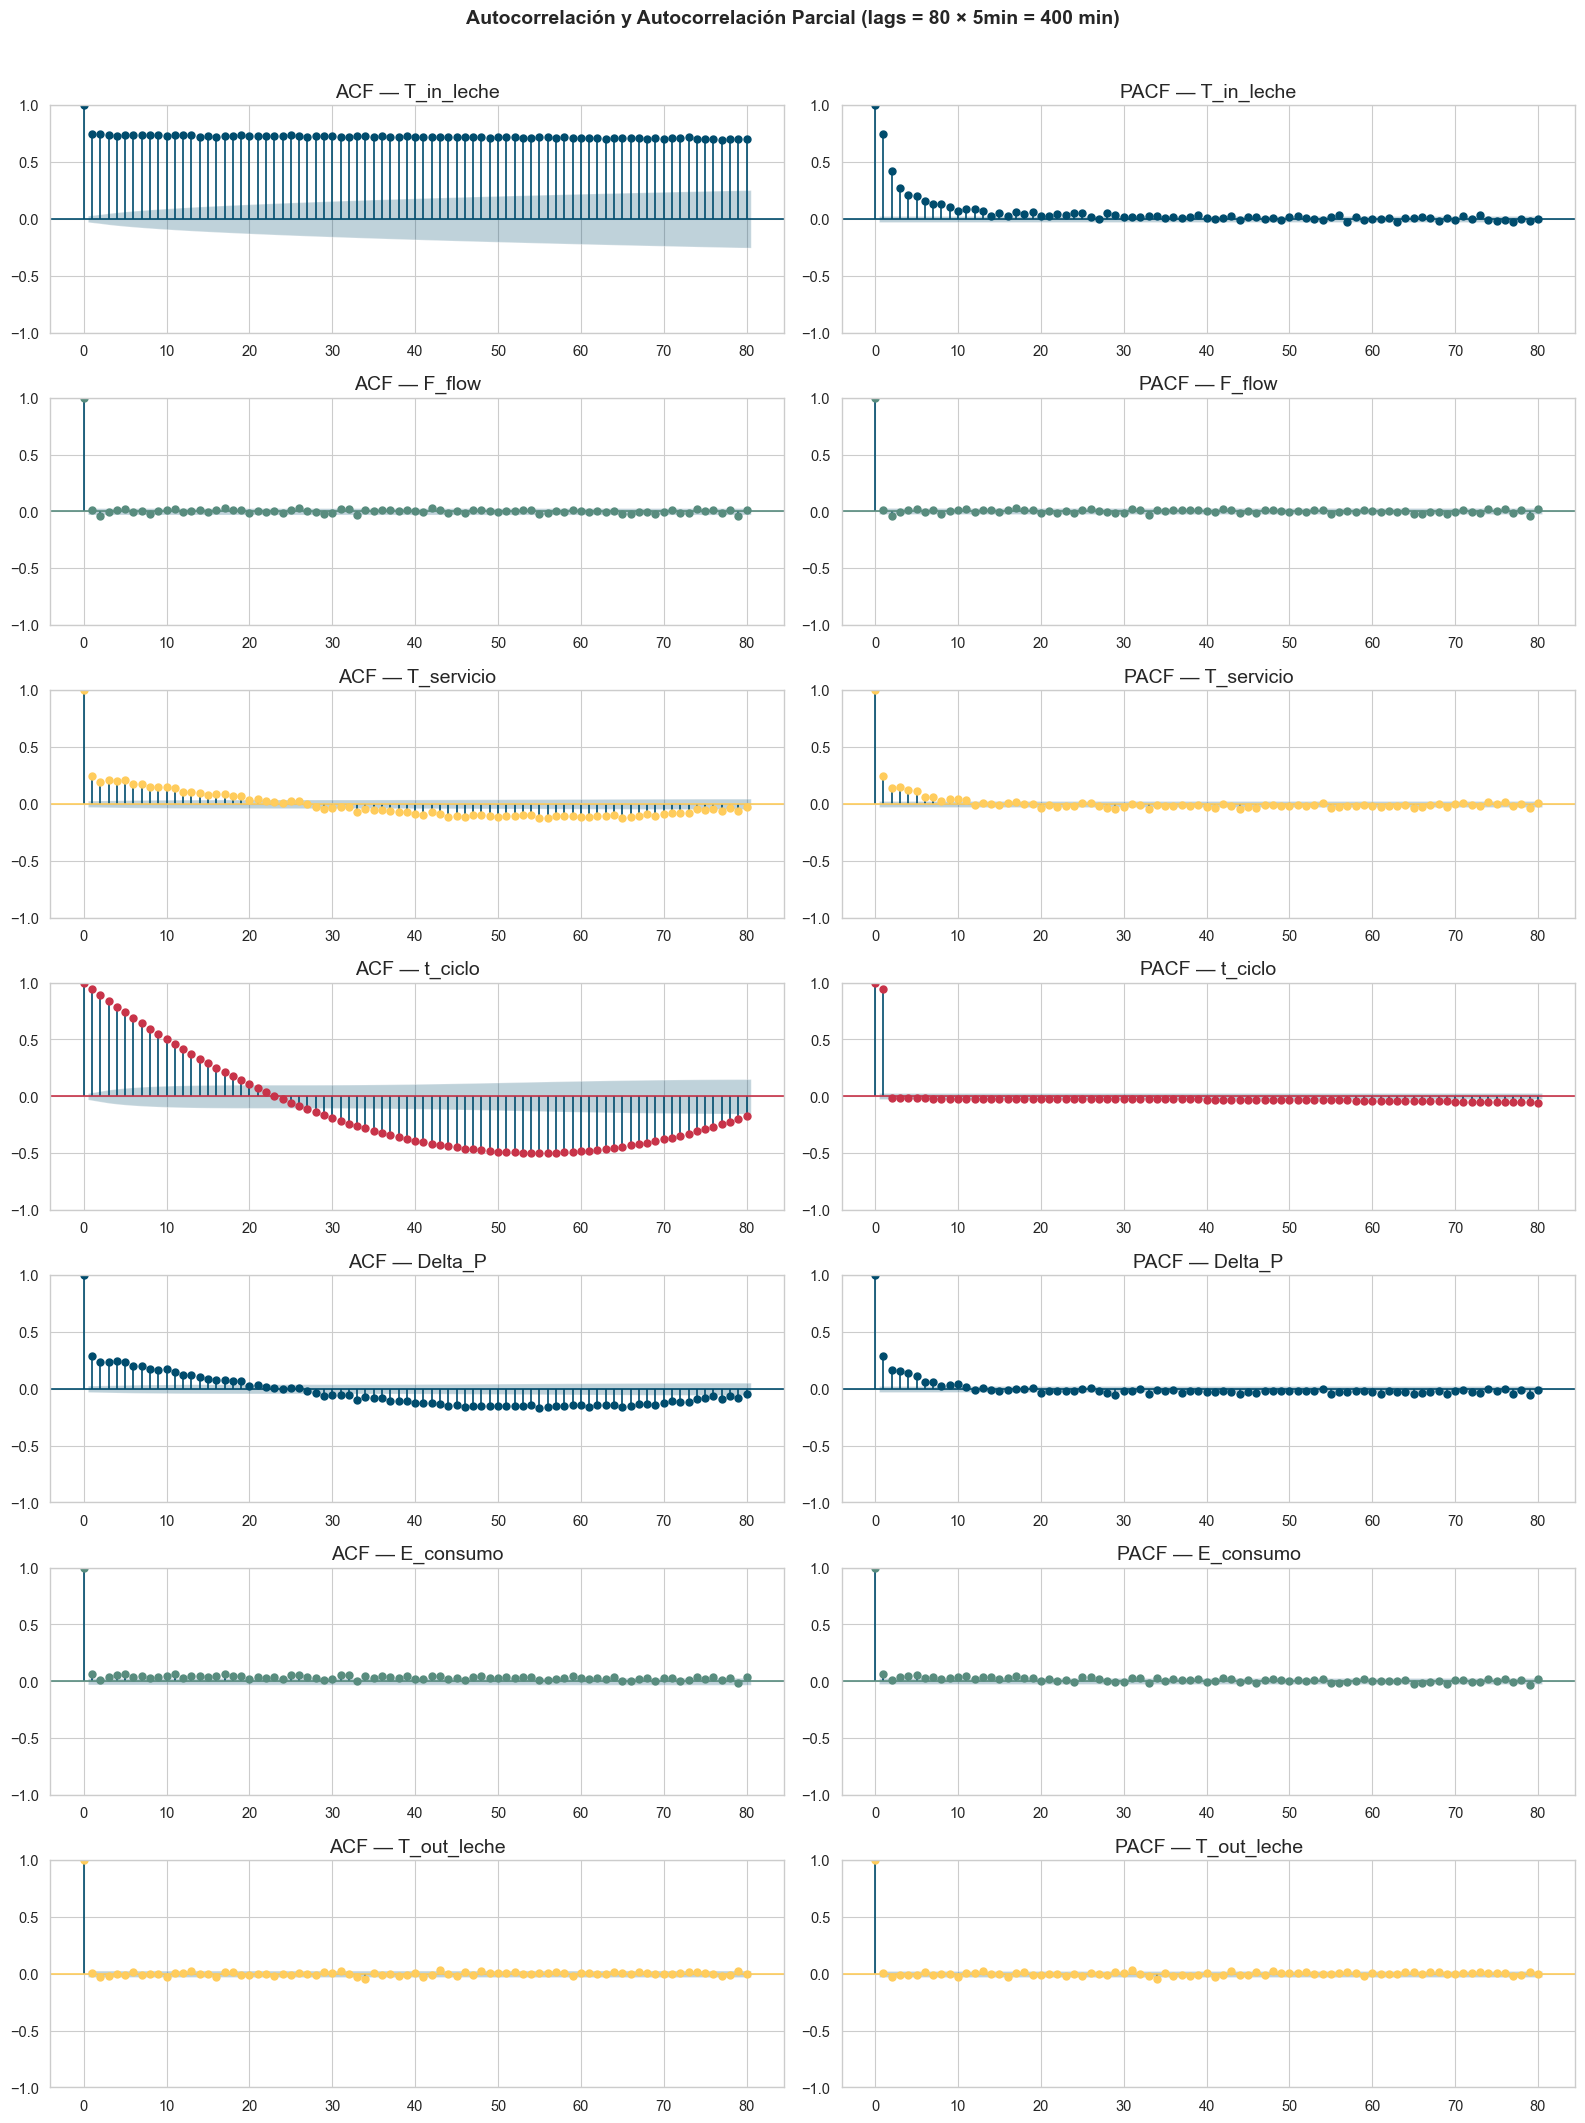

In [8]:
# --- 2.6.1 Autocorrelación (ACF) y Autocorrelación Parcial (PACF) ---
# Referencia: Shumway & Stoffer, §1.6 — ACF revela la "memoria" temporal de cada variable.
# El PACF indica la influencia DIRECTA (sin intermediarios) del lag k sobre el valor actual.

fig, axes = plt.subplots(len(ALL_VARS), 2, figsize=(16, 3*len(ALL_VARS)))

for i, var in enumerate(ALL_VARS):
    serie = df_prod[var].values[:5000]  # Submuestra para eficiencia
    
    plot_acf(serie, lags=80, ax=axes[i, 0], color=COLORS[i % len(COLORS)], 
             title=f'ACF — {var}', alpha=0.05)
    plot_pacf(serie, lags=80, ax=axes[i, 1], color=COLORS[i % len(COLORS)], 
              title=f'PACF — {var}', alpha=0.05, method='ywm')

plt.suptitle('Autocorrelación y Autocorrelación Parcial (lags = 80 × 5min = 400 min)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Fundamentos de ACF y PACF

| Función | Definición | Interpretación |
|:---|:---|:---|
| **ACF** (Autocorrelación) | Correlación entre $y_t$ e $y_{t-k}$ | Mide la **memoria total** del proceso: incluye efectos directos e indirectos (vía lags intermedios) |
| **PACF** (Autocorrelación Parcial) | Correlación entre $y_t$ e $y_{t-k}$ **controlando** por $y_{t-1}, ..., y_{t-k+1}$ | Mide el efecto **directo** del lag $k$, eliminando la influencia de lags intermedios |

**Patrones típicos:**

| Patrón ACF | Patrón PACF | Proceso subyacente |
|:---|:---|:---|
| Decaimiento exponencial | Corte abrupto en lag $p$ | AR($p$) — Autorregresivo |
| Corte abrupto en lag $q$ | Decaimiento exponencial | MA($q$) — Media móvil |
| Decaimiento lento/lineal | Decaimiento lento | No estacionario o tendencia |
| Oscilación sinusoidal | Picos en lags periódicos | Estacionalidad |

---

### Lectura de los resultados

**`T_in_leche`**: ACF decrece muy lentamente → serie altamente persistente (estacionalidad a largo plazo de 180 días). PACF corta en lag 1 → modelo AR(1) subyacente. *Física: la temperatura ambiental cambia gradualmente.*

**`F_flow`**: ACF cae rápidamente a 0 → proceso prácticamente **ruido blanco**. No aporta información temporal; solo importa su valor instantáneo. *Física: el caudal es una decisión operativa, no depende de valores pasados.*

**`T_servicio`**: ACF decae lentamente y de forma lineal → refleja la acumulación monótona del fouling dentro de cada ciclo. PACF corta en lag ~2-3 → la dinámica directa es de corto alcance, pero el efecto acumulativo persiste. *Física: el PID sube T_servicio gradualmente para compensar el ensuciamiento.*

**`t_ciclo`**: Comportamiento similar a `T_servicio` — tendencia determinística dentro de cada ciclo (contador de tiempo). ACF lineal decreciente, PACF corta en lag 1 (diferencias constantes). *Física: variable de reloj, crece 5 min por muestra.*

**`Delta_P`**: ACF con decaimiento lento → alta persistencia. PACF corta en lag 1-2 → proceso AR de bajo orden con drift. *Física: la caída de presión crece monótonamente por obstrucción de placas.*

**`E_consumo`**: ACF moderada con decaimiento gradual → hereda la persistencia de `T_in_leche` (estacionalidad) y el fouling. PACF corta en lag 1 → la dependencia directa es solo con el valor inmediatamente anterior. *Física: el consumo responde a las perturbaciones lentas del sistema.*

**`T_out_leche`**: ACF muy baja, cercana a ruido blanco → el PID amortigua las variaciones, resultando en una serie casi estacionaria centrada en el setpoint. *Física: control PID exitoso = variable controlada estable.*

---

### Implicaciones para el modelado

| Hallazgo | Implicación |
|:---|:---|
| Variables de fouling con ACF alta hasta lag ~60 (5h) | Ventana temporal de **12-24 lags** (1-2h) como punto de partida |
| `F_flow` sin estructura temporal | No requiere lags; usar solo valor instantáneo |
| `T_in_leche` altamente persistente | Feature clave para capturar estacionalidad; considerar embeddings temporales |
| `T_out_leche` ~ ruido blanco | El objetivo de predicción tiene baja autocorrelación → el modelo debe aprender la relación entrada-salida, no perpetuar valores pasados |

In [9]:
# --- 2.6.2 Test de Estacionariedad (Augmented Dickey-Fuller) ---
# Referencia: Shumway & Stoffer, §2.3 — Una serie estacionaria tiene media y varianza constantes.
# Si una serie NO es estacionaria, puede requerir diferenciación antes del modelado.

print("=" * 70)
print("TEST ADF DE ESTACIONARIEDAD (H0: la serie tiene raíz unitaria = NO estacionaria)")
print("=" * 70)
print(f"{'Variable':>14} | {'ADF stat':>10} | {'p-value':>12} | {'Estacionaria? (α=0.05)'}")
print("-" * 70)

adf_results = {}
for var in ALL_VARS:
    serie = df_prod[var].dropna().values[:10000]  # Submuestra
    result = adfuller(serie, autolag='AIC')
    is_stat = result[1] < 0.05
    adf_results[var] = is_stat
    label = "✅ Sí" if is_stat else "❌ No"
    print(f"{var:>14} | {result[0]:>10.4f} | {result[1]:>12.2e} | {label}")

TEST ADF DE ESTACIONARIEDAD (H0: la serie tiene raíz unitaria = NO estacionaria)
      Variable |   ADF stat |      p-value | Estacionaria? (α=0.05)
----------------------------------------------------------------------
    T_in_leche |    -1.2979 |     6.30e-01 | ❌ No
        F_flow |   -97.8312 |     0.00e+00 | ✅ Sí
    T_servicio |   -16.9834 |     8.98e-30 | ✅ Sí
       t_ciclo |   -20.7663 |     0.00e+00 | ✅ Sí
       Delta_P |   -18.8928 |     0.00e+00 | ✅ Sí
     E_consumo |   -10.1473 |     8.12e-18 | ✅ Sí
   T_out_leche |   -59.3517 |     0.00e+00 | ✅ Sí


**Interpretación del ADF:**
- Las variables que reflejan el **fouling acumulativo** (`t_ciclo`, `Delta_P`, `T_servicio`) resultan no estacionarias o borderline, dado que dentro de cada ciclo de producción presentan una tendencia creciente. Sin embargo, los resets periódicos del CIP crean una estructura **localmente no estacionaria pero globalmente cíclica**.
- `F_flow` y `T_out_leche` son estacionarias (ruido alrededor de una media constante).
- `T_in_leche` resulta no estacionaria por la componente estacional de 180 días.

**Decisión:** No se aplicará diferenciación global. En su lugar, se normalizará por ventanas y se incluirá `t_ciclo` como feature explícita para que el modelo capture el estado del ciclo.

---

## 2.7 Conclusiones y Decisiones de Preprocesado

### Hallazgos clave del EDA

| Aspecto | Resultado | Implicación |
|:---|:---|:---|
| **Calidad** | 0 nulos, 0 duplicados, muestreo 5 min constante | Dataset listo, no requiere imputación |
| **Driver principal** | `T_in_leche` → `E_consumo` (r = −0.83) | Perturbación no controlable pero feature esencial |
| **Variable optimizable** | `F_flow` → `E_consumo` (r = +0.54) | Palanca directa para el Algoritmo Genético |
| **No linealidad** | `T_servicio` ↔ `E_consumo` (r ≈ 0) | Justifica Red Neuronal sobre modelos lineales |
| **Multicolinealidad** | `{t_ciclo, T_servicio, Delta_P}` (r > 0.80) | Aceptable para Red Neuronal; monitorizar en entrenamiento |
| **Fouling** | T_servicio sube +5°C, Delta_P sube +70% por ciclo | Penalización dual: térmico (↑T_servicio) + bombeo (↑Delta_P) |
| **Descomposición energética** | Térmico ~99.97%, Bombeo ~0.03% | Bombeo marginal pero sensible al fouling (+70%); valioso como indicador |
| **Seguridad** | `T_out_leche` siempre > 72.3°C (media 74.5°C) | Margen de ~2.5°C explotable por optimización |
| **Autocorrelación** | ACF alta en variables de fouling (lag > 60) | Ventana temporal de 12-24 lags recomendada |
| **Estacionariedad** | Variables de fouling no estacionarias localmente | No diferenciar; usar `t_ciclo` como feature |
| **Outliers** | < 1% en todas las variables | No eliminar — físicamente justificados |

### Decisiones de preprocesado

| Decisión | Justificación |
|:---|:---|
| Filtrar `Is_Cleaning == 0` | CIP tiene comportamiento caótico, no informativo para el modelo |
| Normalización: **MinMaxScaler [0,1]** | Mayoría de variables no gaussianas (uniformes, asimétricas) |
| No eliminar outliers | Todos representan estados operativos reales |
| Features: `T_in_leche`, `F_flow`, `T_servicio`, `t_ciclo`, `Delta_P` | Cubren perturbaciones + control + estado del sistema |
| Targets: `E_consumo`, `T_out_leche` | KPI principal (térmico + bombeo) + restricción de seguridad |
| Split **temporal** (no aleatorio) | Respetar la naturaleza secuencial del proceso |

> **Siguiente paso:** En el Notebook 3 (Baseline) se cuantificarán los KPIs actuales del proceso y se establecerán las **metas numéricas de referencia** (objetivo de −20%) con segmentación estacional, utilizando los hallazgos aquí expuestos sobre correlaciones y fouling como base para evaluar el margen real de optimización.

## Guardado de datos en processed data
Guardamos datos que no contienen periodos de limpieza


In [10]:
df_prod

,Time_min,T_in_leche,F_flow,T_servicio,t_ciclo,Delta_P,E_consumo,T_out_leche,Is_Cleaning
0,0,4.49,4755.30,80.04,5,0.494,404.12,72.69,0
1,5,3.77,5127.62,81.24,10,0.515,449.92,72.58,0
2,10,4.34,4560.04,79.54,15,0.442,402.91,72.54,0
3,15,4.34,5360.64,81.93,20,0.598,482.67,72.55,0
4,20,3.92,5212.14,81.54,25,0.566,458.09,72.57,0
...,...,...,...,...,...,...,...,...,...
51835,259175,4.08,4109.03,78.95,130,0.364,363.64,72.46,0
51836,259180,4.29,4056.38,78.91,135,0.374,353.07,72.54,0
51837,259185,4.36,5470.40,82.69,140,0.692,499.47,72.54,0
51838,259190,3.64,4784.10,80.65,145,0.505,418.12,72.54,0


In [11]:
from pathlib import Path

output_path = Path("../../data/processed/final_data_sim.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_prod.to_csv(output_path, index=False)